## Import necessary libraries

In [1]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import kagglehub
import pickle
import re
import os

## Download and transform data

In [2]:
path = kagglehub.dataset_download("dawidcegielski/house-prices-in-poland")

print(path)

data = pd.read_csv(os.path.join(path, "Houses.csv"), encoding="windows-1250")

data.head()

/home/mz/.cache/kagglehub/datasets/dawidcegielski/house-prices-in-poland/versions/1


,Unnamed: 0,address,city,floor,id,latitude,longitude,price,rooms,sq,year
0,0,Podgórze Zabłocie Stanisława Klimeckiego,Kraków,2.0,23918.0,50.049224,19.970379,749000.0,3.0,74.05,2021.0
1,1,Praga-Południe Grochowska,Warszawa,3.0,17828.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0
2,2,Krowodrza Czarnowiejska,Kraków,2.0,22784.0,50.066964,19.920025,427000.0,2.0,37.00,1970.0
3,3,Grunwald,Poznań,2.0,4315.0,52.404212,16.882542,1290000.0,5.0,166.00,1935.0
4,4,Ochota Gotowy budynek. Stan deweloperski. Osta...,Warszawa,1.0,11770.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0


In [3]:
data.shape

(23764, 11)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23764 entries, 0 to 23763
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  23764 non-null  int64  
 1   address     23764 non-null  object 
 2   city        23764 non-null  object 
 3   floor       23764 non-null  float64
 4   id          23764 non-null  float64
 5   latitude    23764 non-null  float64
 6   longitude   23764 non-null  float64
 7   price       23764 non-null  float64
 8   rooms       23764 non-null  float64
 9   sq          23764 non-null  float64
 10  year        23764 non-null  float64
dtypes: float64(8), int64(1), object(2)
memory usage: 2.0+ MB


#### Drop unecessary features

In [5]:
data = data.drop(["Unnamed: 0", "id"], axis=1)

data.head()

,address,city,floor,latitude,longitude,price,rooms,sq,year
0,Podgórze Zabłocie Stanisława Klimeckiego,Kraków,2.0,50.049224,19.970379,749000.0,3.0,74.05,2021.0
1,Praga-Południe Grochowska,Warszawa,3.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0
2,Krowodrza Czarnowiejska,Kraków,2.0,50.066964,19.920025,427000.0,2.0,37.00,1970.0
3,Grunwald,Poznań,2.0,52.404212,16.882542,1290000.0,5.0,166.00,1935.0
4,Ochota Gotowy budynek. Stan deweloperski. Osta...,Warszawa,1.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0


#### Drop outliers in year feature

In [6]:
data["year"].describe()

count    23764.00000
mean      2000.55117
std         48.31402
min         70.00000
25%       1985.00000
50%       2019.00000
75%       2021.00000
max       2980.00000
Name: year, dtype: float64

In [7]:
data = data[(data["year"] >= 1950) & (data["year"] <= 2021)]

data.shape

(19144, 9)

#### Check city feature

In [8]:
data["city"].unique()

array(['Kraków', 'Warszawa', 'Poznań'], dtype=object)

Text(0, 0.5, 'Number of data points')

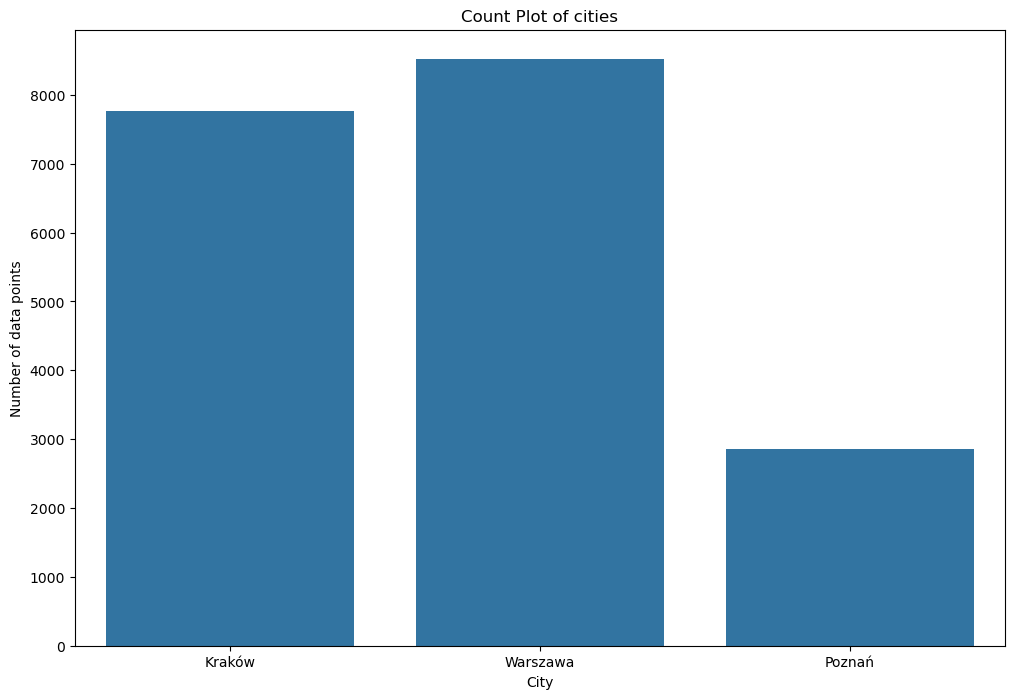

In [9]:
plt.figure(figsize=(12,8))
fig = sns.countplot(x=data["city"])
fig.set_title("Count Plot of cities")
fig.set_xlabel("City")
fig.set_ylabel("Number of data points")

#### Clean coordinate outliers

Text(0, 0.5, 'Latitude')

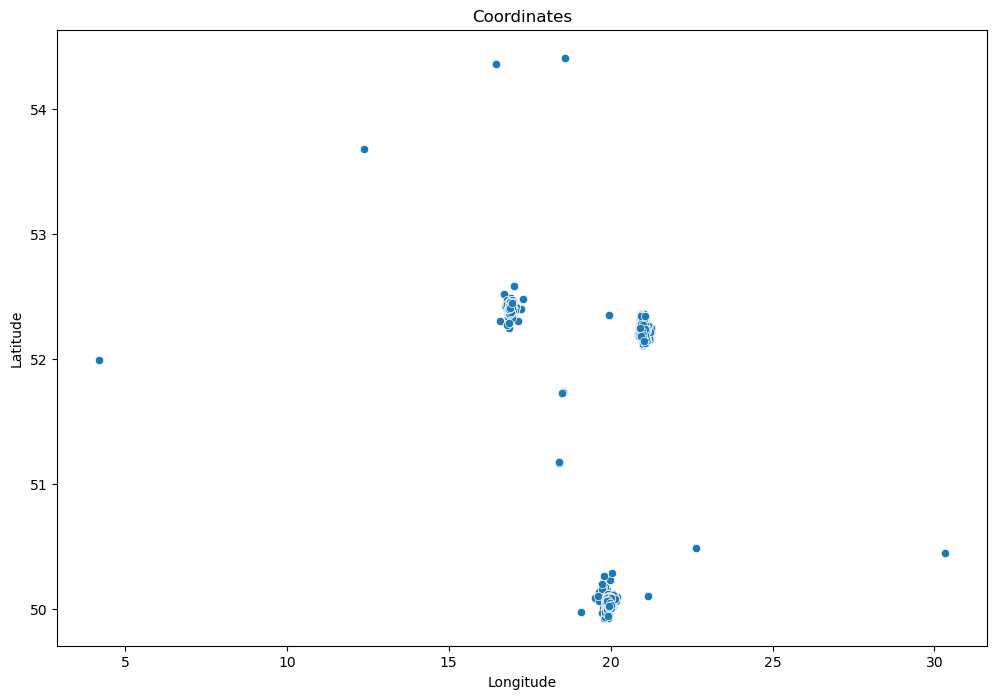

In [10]:
plt.figure(figsize=(12,8))
fig = sns.scatterplot(data=data, x="longitude", y="latitude")
fig.set_title("Coordinates")
fig.set_xlabel("Longitude")
fig.set_ylabel("Latitude")

In [11]:
data = data[(data["longitude"] >= 16) & (data["longitude"] <= 22)]
data = data[(data["latitude"] >= 48) & (data["latitude"] <= 53)]

data.shape

(19121, 9)

Text(0, 0.5, 'Latitude')

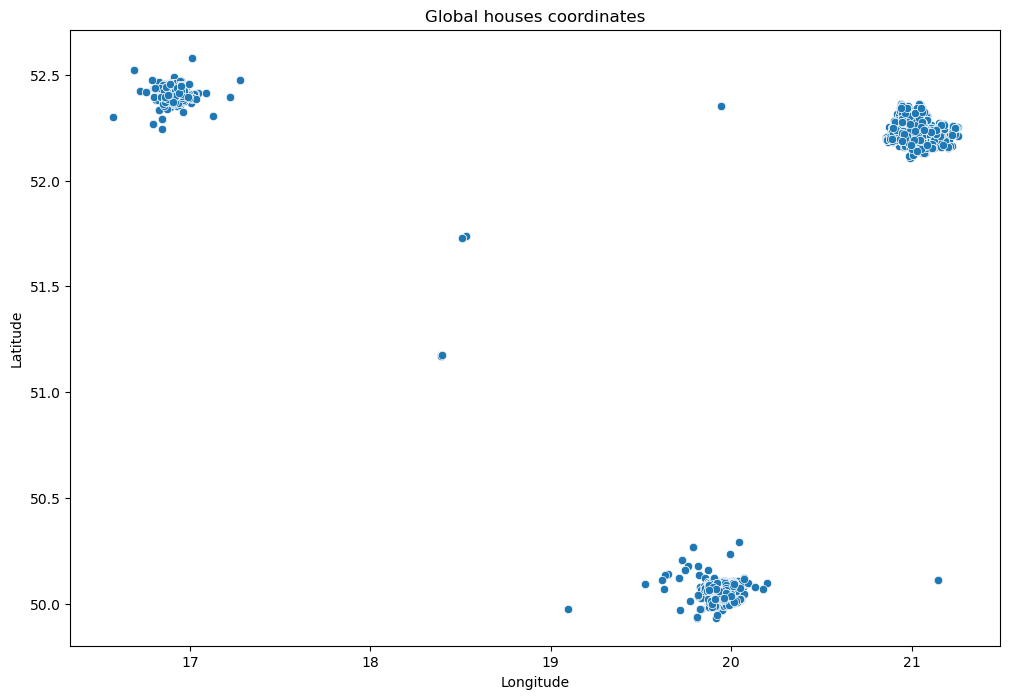

In [12]:
plt.figure(figsize=(12,8))
fig = sns.scatterplot(data=data, x="longitude", y="latitude")
fig.set_title("Global houses coordinates")
fig.set_xlabel("Longitude")
fig.set_ylabel("Latitude")

## Warsaw data cleaning

In [13]:
warsaw_data = data[data["city"] == "Warszawa"]

warsaw_data.head()

,address,city,floor,latitude,longitude,price,rooms,sq,year
1,Praga-Południe Grochowska,Warszawa,3.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0
4,Ochota Gotowy budynek. Stan deweloperski. Osta...,Warszawa,1.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0
7,Mokotów Pory,Warszawa,10.0,52.184058,21.044302,2890000.0,6.0,280.00,2003.0
8,Ursynów Wyżyny,Warszawa,3.0,52.140282,21.056345,615000.0,4.0,63.40,1982.0
9,Bemowo,Warszawa,1.0,52.238974,20.913288,429000.0,1.0,40.00,1999.0


In [14]:
warsaw_data.shape

(8509, 9)

#### Drop coordinate outliers

In [15]:
warsaw_data = warsaw_data[(warsaw_data["longitude"] >= 20.7) & (warsaw_data["longitude"] <= 21.3)]
warsaw_data = warsaw_data[(warsaw_data["latitude"] >= 52) & (warsaw_data["latitude"] <= 52.4)]

warsaw_data.shape

(8498, 9)

#### Extract districts from addresses

In [16]:
warsaw_districts = ["Śródmieście", "Mokotów", "Ochota", "Wola", "Żoliborz", "Praga-Południe", "Praga-Północ",
                    "Bemowo", "Białołęka", "Bielany", "Rembertów", "Targówek", "Ursus", "Ursynów", "Wawer",
                    "Wesoła", "Wilanów", "Włochy"]

pattern = r"\b(" + "|".join(map(re.escape, warsaw_districts)) + r")\b"

warsaw_data["district"] = warsaw_data["address"].str.extract(
    pattern,
    flags=re.IGNORECASE,
    expand=False
)

warsaw_data["district"].unique()

array(['Praga-Południe', 'Ochota', 'Mokotów', 'Ursynów', 'Bemowo',
       'Śródmieście', 'Białołęka', 'Wola', 'Praga-Północ', 'Wilanów',
       'Włochy', 'Żoliborz', 'Ursus', 'Bielany', 'Targówek', 'Wawer', nan,
       'Wesoła', 'Rembertów'], dtype=object)

In [17]:
warsaw_data = warsaw_data.dropna(subset=["district"])

warsaw_data.shape

(8385, 10)

In [18]:
warsaw_data = warsaw_data.drop(["address"], axis=1)

In [19]:
warsaw_data.head()

,city,floor,latitude,longitude,price,rooms,sq,year,district
1,Warszawa,3.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0,Praga-Południe
4,Warszawa,1.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0,Ochota
7,Warszawa,10.0,52.184058,21.044302,2890000.0,6.0,280.00,2003.0,Mokotów
8,Warszawa,3.0,52.140282,21.056345,615000.0,4.0,63.40,1982.0,Ursynów
9,Warszawa,1.0,52.238974,20.913288,429000.0,1.0,40.00,1999.0,Bemowo


#### Check coordinates and district features

Text(0, 0.5, 'Latitude')

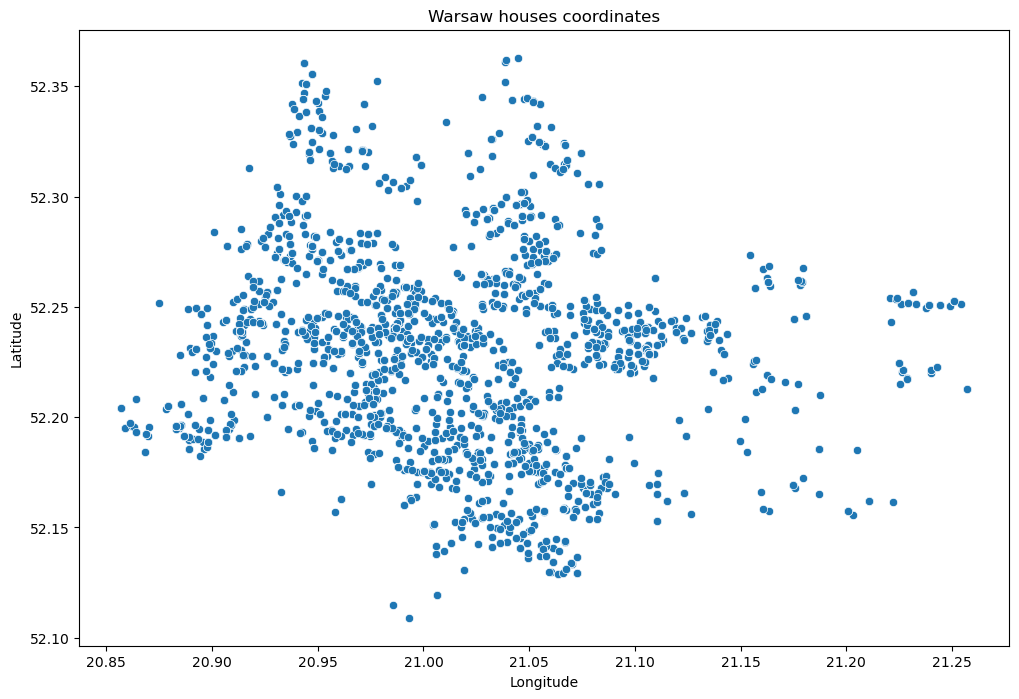

In [20]:
plt.figure(figsize=(12,8))
fig = sns.scatterplot(data=warsaw_data, x="longitude", y="latitude")
fig.set_title("Warsaw houses coordinates")
fig.set_xlabel("Longitude")
fig.set_ylabel("Latitude")

Text(0, 0.5, 'Number of data points')

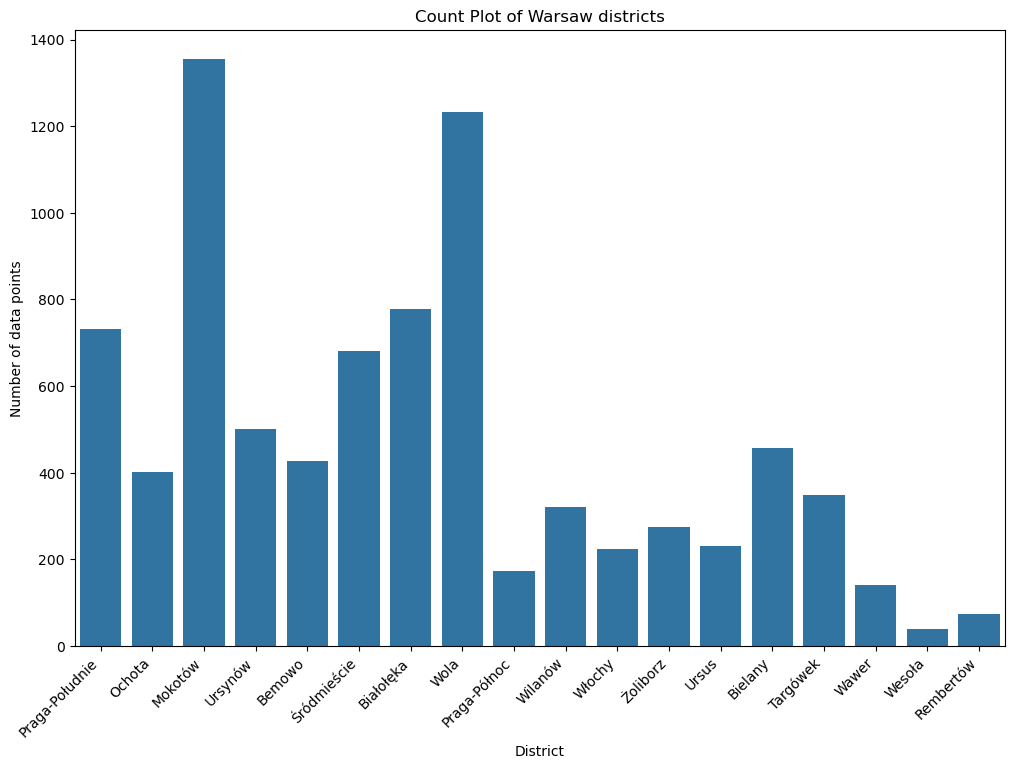

In [21]:
plt.figure(figsize=(12,8))
plt.xticks(rotation=45, ha='right')
fig = sns.countplot(x=warsaw_data["district"])
fig.set_title("Count Plot of Warsaw districts")
fig.set_xlabel("District")
fig.set_ylabel("Number of data points")

## Kraków data cleaning

In [22]:
krakow_data = data[data["city"] == "Kraków"]

krakow_data.head()

,address,city,floor,latitude,longitude,price,rooms,sq,year
0,Podgórze Zabłocie Stanisława Klimeckiego,Kraków,2.0,50.049224,19.970379,749000.0,3.0,74.05,2021.0
2,Krowodrza Czarnowiejska,Kraków,2.0,50.066964,19.920025,427000.0,2.0,37.00,1970.0
6,Podgórze Płaszów Koszykarska,Kraków,0.0,50.049893,19.990603,750000.0,4.0,81.40,2021.0
26,Prądnik Czerwony ul. Śliczna,Kraków,1.0,50.046943,19.997153,756707.4,4.0,82.43,2021.0
30,Dębniki Ruczaj prof. Michała Bobrzyńskiego,Kraków,4.0,50.020627,19.898190,699000.0,2.0,60.00,2010.0


In [23]:
krakow_data.shape

(7756, 9)

#### Drop coordinate outliers

In [24]:
krakow_data = krakow_data[(krakow_data["longitude"] >= 19.8) & (krakow_data["longitude"] <= 20.2)]
krakow_data = krakow_data[(krakow_data["latitude"] >= 49.9) & (krakow_data["latitude"] <= 50.2)]

krakow_data.shape

(7668, 9)

#### Extract districts from addresses

In [25]:
krakow_districts = ["Stare Miasto", "Grzegórzki", "Prądnik Czerwony", "Prądnik Biały", "Krowodrza",
                    "Bronowice", "Zwierzyniec", "Dębniki", "Łagiewniki-Borek Fałęcki", "Swoszowice",
                    "Podgórze Duchackie", "Bieżanów-Prokocim", "Podgórze", "Nowa Huta Czyżyny", "Mistrzejowice",
                    "Bieńczyce", "Wzgórza Krzesławickie", "Nowa Huta"]

pattern = r"\b(" + "|".join(map(re.escape, krakow_districts)) + r")\b"

krakow_data["district"] = krakow_data["address"].str.extract(
    pattern,
    flags=re.IGNORECASE,
    expand=False
)

krakow_data["district"].unique()

array(['Podgórze', 'Krowodrza', 'Prądnik Czerwony', 'Dębniki',
       'Stare Miasto', 'Podgórze Duchackie', 'Zwierzyniec', 'Grzegórzki',
       'Nowa Huta Czyżyny', 'Bronowice', 'Bieżanów-Prokocim', 'Nowa Huta',
       nan, 'Mistrzejowice', 'Prądnik Biały', 'Łagiewniki-Borek Fałęcki',
       'Bieńczyce', 'Wzgórza Krzesławickie', 'Swoszowice'], dtype=object)

In [26]:
krakow_data = krakow_data.dropna(subset=["district"])

krakow_data.shape

(7452, 10)

In [27]:
krakow_data = krakow_data.drop(["address"], axis=1)

In [28]:
krakow_data.head()

,city,floor,latitude,longitude,price,rooms,sq,year,district
0,Kraków,2.0,50.049224,19.970379,749000.0,3.0,74.05,2021.0,Podgórze
2,Kraków,2.0,50.066964,19.920025,427000.0,2.0,37.00,1970.0,Krowodrza
6,Kraków,0.0,50.049893,19.990603,750000.0,4.0,81.40,2021.0,Podgórze
26,Kraków,1.0,50.046943,19.997153,756707.4,4.0,82.43,2021.0,Prądnik Czerwony
30,Kraków,4.0,50.020627,19.898190,699000.0,2.0,60.00,2010.0,Dębniki


#### Check coordinate and district features

Text(0, 0.5, 'Latitude')

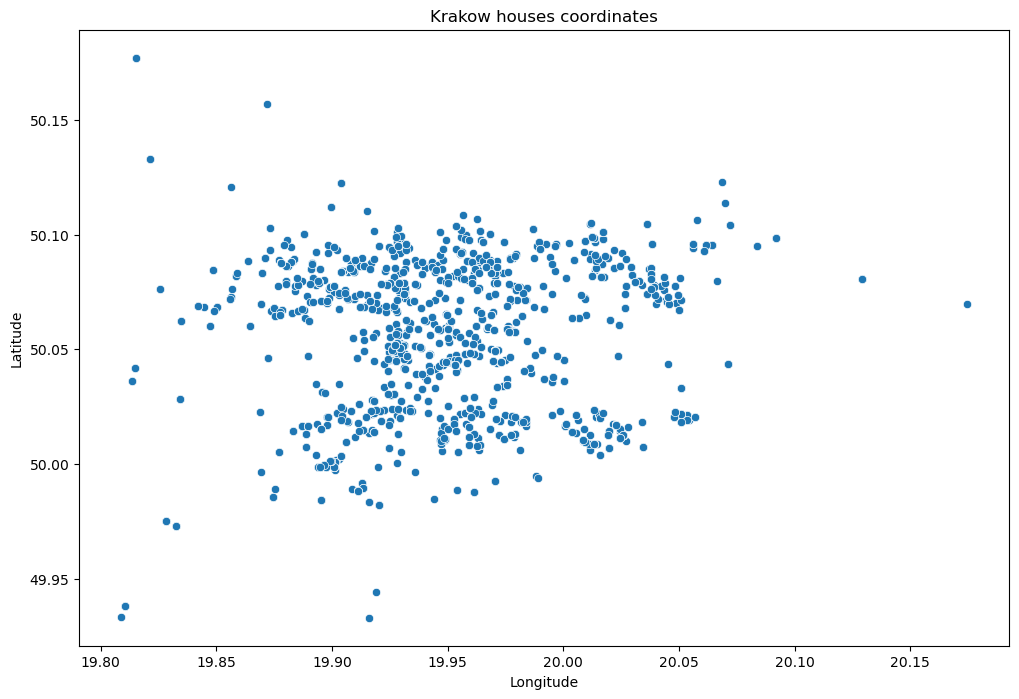

In [29]:
plt.figure(figsize=(12,8))
fig = sns.scatterplot(data=krakow_data, x="longitude", y="latitude")
fig.set_title("Krakow houses coordinates")
fig.set_xlabel("Longitude")
fig.set_ylabel("Latitude")

Text(0, 0.5, 'Number of data points')

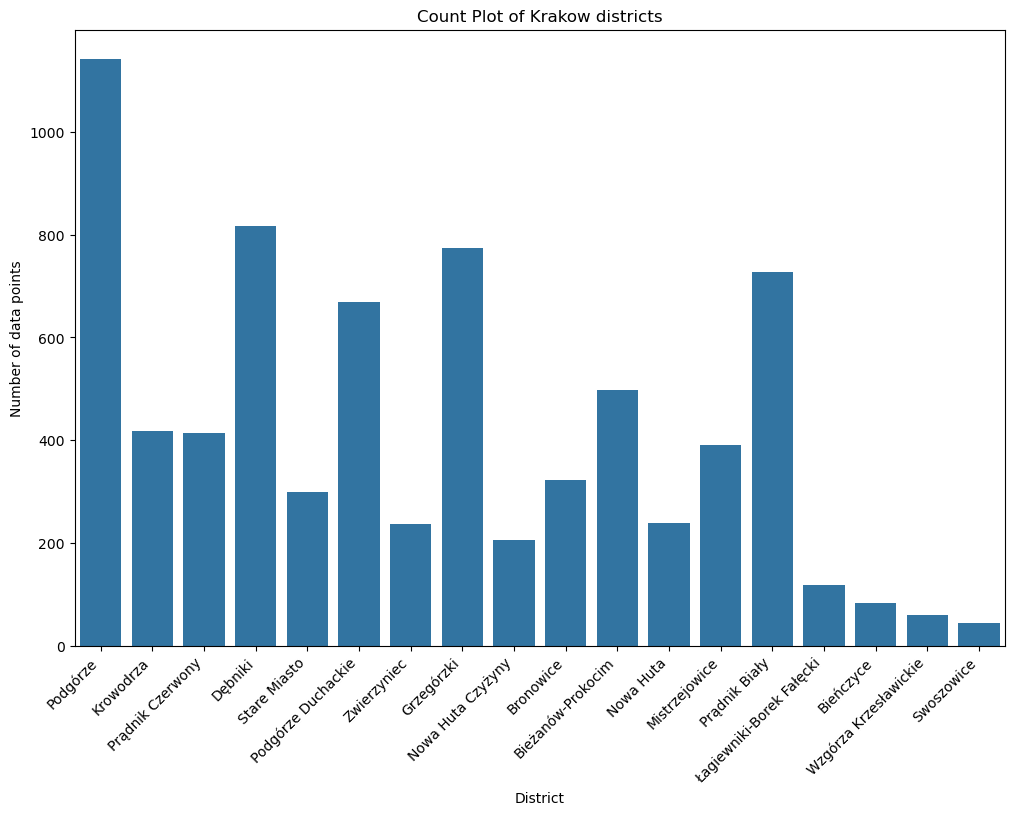

In [30]:
plt.figure(figsize=(12,8))
plt.xticks(rotation=45, ha='right')
fig = sns.countplot(x=krakow_data["district"])
fig.set_title("Count Plot of Krakow districts")
fig.set_xlabel("District")
fig.set_ylabel("Number of data points")

## Poznań data cleaning

In [31]:
poznan_data = data[data["city"] == "Poznań"]

poznan_data.head()

,address,city,floor,latitude,longitude,price,rooms,sq,year
13,Nowe Miasto Malta Florentyny Luboińskiej 5,Poznań,0.0,52.391608,16.994063,421427.0,3.0,60.29,2019.0
15,Grunwald Świerzawska,Poznań,8.0,52.400663,16.919733,547000.0,4.0,77.39,2020.0
17,Grunwald Górczyn ul. Ceglana,Poznań,1.0,52.370993,16.863146,618636.0,3.0,66.52,2020.0
24,Stare Miasto Wilczak Wilczak 16 A,Poznań,1.0,52.430092,16.951473,442700.0,3.0,58.25,2020.0
25,Jeżyce,Poznań,4.0,52.413045,16.902212,496369.0,2.0,41.57,2020.0


In [32]:
poznan_data.shape

(2856, 9)

#### Drop coordinate outliers

In [33]:
poznan_data = poznan_data[(poznan_data["longitude"] >= 16.6) & (poznan_data["longitude"] <= 17.2)]
poznan_data = poznan_data[(poznan_data["latitude"] >= 52.2) & (poznan_data["latitude"] <= 52.5)]

poznan_data.shape

(2842, 9)

#### Extract districts from addresses

In [34]:
poznan_districts = ["Stare Miasto Piątkowo", "Stare Miasto", "Grunwald Łazarz", "Jeżyce", "Wilda", "Grunwald",
                    "Nowe Miasto"]

pattern = r"\b(" + "|".join(map(re.escape, poznan_districts)) + r")\b"

poznan_data["district"] = poznan_data["address"].str.extract(
    pattern,
    flags=re.IGNORECASE,
    expand=False
)

poznan_data["district"].unique()

array(['Nowe Miasto', 'Grunwald', 'Stare Miasto', 'Jeżyce', 'Wilda',
       'Stare Miasto Piątkowo', 'Grunwald Łazarz', nan], dtype=object)

In [35]:
poznan_data = poznan_data.dropna(subset=["district"])

poznan_data.shape

(2764, 10)

In [36]:
poznan_data = poznan_data.drop(["address"], axis=1)

In [37]:
poznan_data.head()

,city,floor,latitude,longitude,price,rooms,sq,year,district
13,Poznań,0.0,52.391608,16.994063,421427.0,3.0,60.29,2019.0,Nowe Miasto
15,Poznań,8.0,52.400663,16.919733,547000.0,4.0,77.39,2020.0,Grunwald
17,Poznań,1.0,52.370993,16.863146,618636.0,3.0,66.52,2020.0,Grunwald
24,Poznań,1.0,52.430092,16.951473,442700.0,3.0,58.25,2020.0,Stare Miasto
25,Poznań,4.0,52.413045,16.902212,496369.0,2.0,41.57,2020.0,Jeżyce


#### Check coordinate and district features

Text(0, 0.5, 'Latitude')

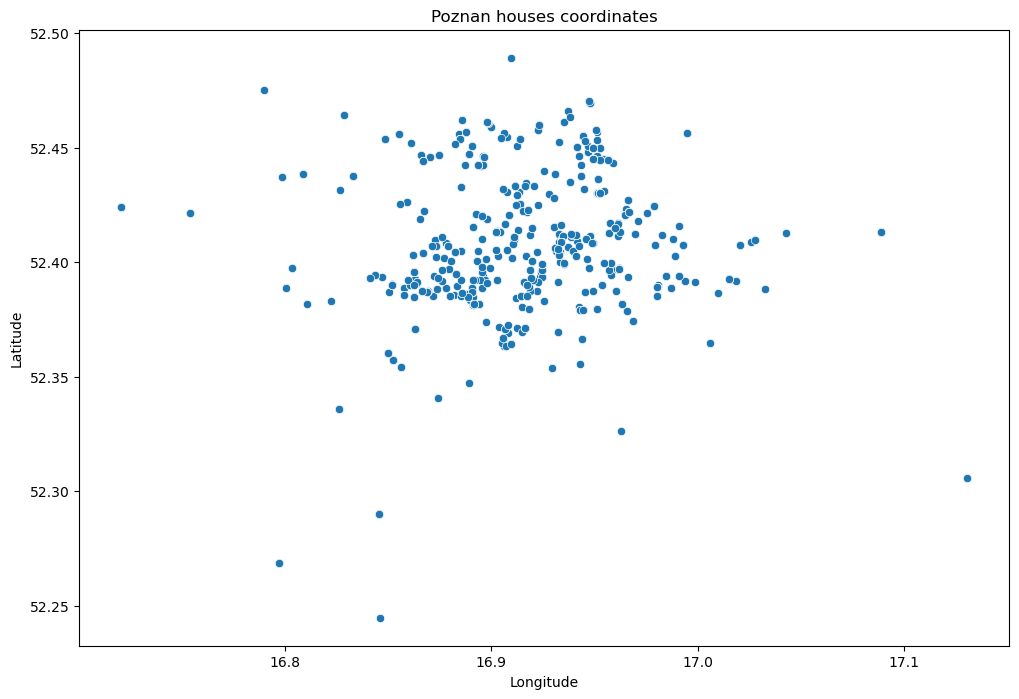

In [38]:
plt.figure(figsize=(12,8))
fig = sns.scatterplot(data=poznan_data, x="longitude", y="latitude")
fig.set_title("Poznan houses coordinates")
fig.set_xlabel("Longitude")
fig.set_ylabel("Latitude")

Text(0, 0.5, 'Number of data points')

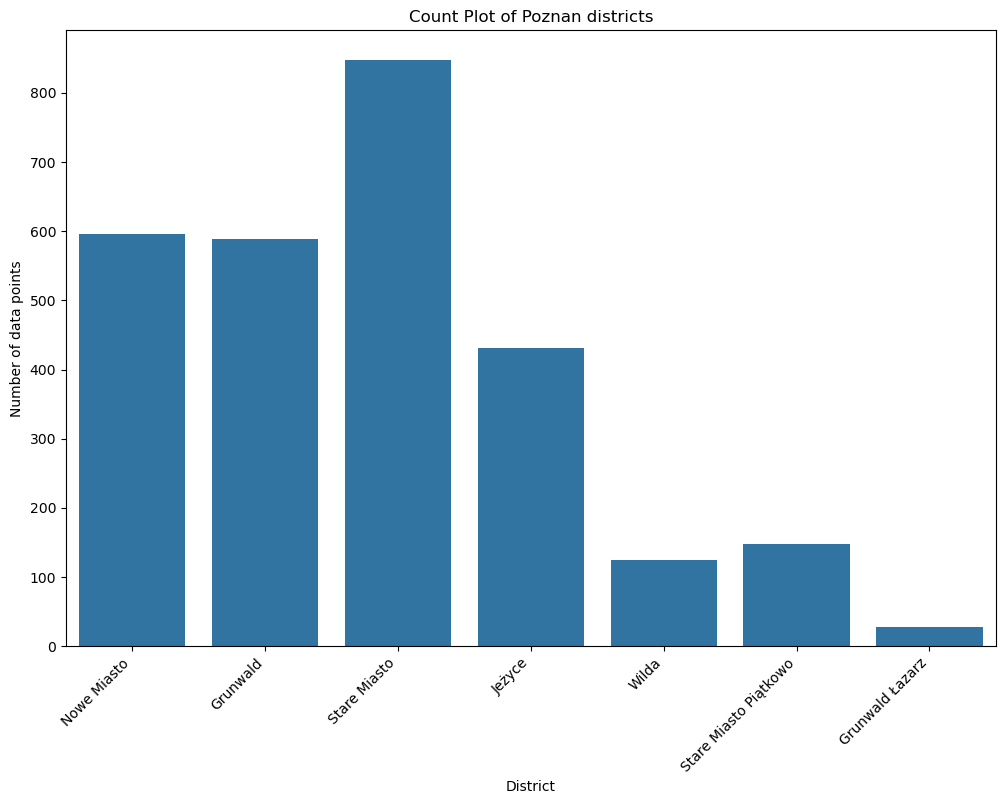

In [39]:
plt.figure(figsize=(12,8))
plt.xticks(rotation=45, ha='right')
fig = sns.countplot(x=poznan_data["district"])
fig.set_title("Count Plot of Poznan districts")
fig.set_xlabel("District")
fig.set_ylabel("Number of data points")

## Train model

In [40]:
training_data = pd.concat([warsaw_data, krakow_data, poznan_data], ignore_index=True)

training_data.head()

,city,floor,latitude,longitude,price,rooms,sq,year,district
0,Warszawa,3.0,52.249775,21.106886,240548.0,1.0,24.38,2021.0,Praga-Południe
1,Warszawa,1.0,52.212225,20.972630,996000.0,5.0,105.00,2020.0,Ochota
2,Warszawa,10.0,52.184058,21.044302,2890000.0,6.0,280.00,2003.0,Mokotów
3,Warszawa,3.0,52.140282,21.056345,615000.0,4.0,63.40,1982.0,Ursynów
4,Warszawa,1.0,52.238974,20.913288,429000.0,1.0,40.00,1999.0,Bemowo


In [41]:
training_data["city"] = training_data["city"].astype("category")
training_data["district"] = training_data["district"].astype("category")

In [42]:
training_data.shape

(18601, 9)

In [43]:
training_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18601 entries, 0 to 18600
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   city       18601 non-null  category
 1   floor      18601 non-null  float64 
 2   latitude   18601 non-null  float64 
 3   longitude  18601 non-null  float64 
 4   price      18601 non-null  float64 
 5   rooms      18601 non-null  float64 
 6   sq         18601 non-null  float64 
 7   year       18601 non-null  float64 
 8   district   18601 non-null  category
dtypes: category(2), float64(7)
memory usage: 1.0 MB


#### Drop unecessary features

In [44]:
training_data = training_data.drop(["latitude", "longitude", "year"], axis=1)

training_data.head()

,city,floor,price,rooms,sq,district
0,Warszawa,3.0,240548.0,1.0,24.38,Praga-Południe
1,Warszawa,1.0,996000.0,5.0,105.00,Ochota
2,Warszawa,10.0,2890000.0,6.0,280.00,Mokotów
3,Warszawa,3.0,615000.0,4.0,63.40,Ursynów
4,Warszawa,1.0,429000.0,1.0,40.00,Bemowo


#### Divide data to training and test sets

In [45]:
X = training_data.drop(["price"], axis=1)
y = training_data["price"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8, shuffle=True)

#### Build pipeline and find best hiperparameters for Random Forest Regressor

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["city", "district"]),
        ("num", "passthrough", ["floor", "rooms", "sq"])
    ]
)

pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=8))
])

In [48]:
param_dist_rf = {
    "regressor__n_estimators": [50, 60, 70, 80, 90, 100],
    "regressor__max_depth": [None, 10, 20, 30, 40, 50, 60],
    "regressor__min_samples_leaf": [1, 2, 3],
    "regressor__min_samples_split": [2, 3, 4, 5, 6, 7],
    "regressor__max_features": [1.0, "sqrt", "log2"]
}

In [49]:
search_rf = RandomizedSearchCV(
    pipeline_rf,
    param_dist_rf,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=8,
    n_jobs=-1,
    verbose=1
)

search_rf.fit(X_train, y_train)

print(search_rf.best_params_)
print(search_rf.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'regressor__n_estimators': 60, 'regressor__min_samples_split': 3, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 'sqrt', 'regressor__max_depth': None}
0.8256061854093097


In [50]:
reg_rf = search_rf.best_estimator_
y_pred = reg_rf.predict(X_test)

print("Root mean squared error:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("r2 score:", r2_score(y_test, y_pred))

Root mean squared error: 203768.69008828112
Mean absolute error: 82425.37978242725
r2 score: 0.838526245424938


#### Build pipeline and find best hiperparameters for Gradient Boosting Regressor

In [51]:
pipeline_gb = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingRegressor(random_state=8))
])

In [52]:
param_dist_gb = {
    "regressor__n_estimators": [400, 500, 600],
    "regressor__learning_rate": [0.01, 0.05, 0.1, 0.5],
    "regressor__max_depth": [2, 3, 4, 5, 6],
    "regressor__subsample": [0.8, 0.9, 1.0],
    "regressor__min_samples_leaf": [1, 2, 3]
}

In [53]:
search_gb = RandomizedSearchCV(
    pipeline_gb,
    param_dist_gb,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=8,
    n_jobs=-1,
    verbose=1
)

search_gb.fit(X_train, y_train)

print(search_gb.best_params_)
print(search_gb.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
{'regressor__subsample': 1.0, 'regressor__n_estimators': 500, 'regressor__min_samples_leaf': 2, 'regressor__max_depth': 4, 'regressor__learning_rate': 0.1}
0.8167124592812727


In [54]:
reg_gb = search_gb.best_estimator_
y_pred = reg_gb.predict(X_test)

print("Root mean squared error:", mean_squared_error(y_test, y_pred) ** 0.5)
print("Mean absolute error:", mean_absolute_error(y_test, y_pred))
print("r2 score:", r2_score(y_test, y_pred))

Root mean squared error: 203657.84123115777
Mean absolute error: 96937.33635757568
r2 score: 0.8387018790085135


#### Test models on single samples

In [55]:
warsaw_sample = pd.DataFrame([{
    "city": "Warszawa",
    "district": "Mokotów",
    "rooms": 2,
    "sq": 43.64,
    "floor": 5
}])

krakow_sample = pd.DataFrame([{
    "city": "Kraków",
    "district": "Podgórze",
    "rooms": 2,
    "sq": 34.74,
    "floor": 3
}])

poznan_sample = pd.DataFrame([{
    "city": "Poznań",
    "district": "Stare Miasto",
    "rooms": 3,
    "sq": 62.95,
    "floor": 0
}])

print("Random Forest Classifier")
print(f"Warsaw price predict: {reg_rf.predict(warsaw_sample)[0]:.2f} PLN")
print(f"Krakow price predict: {reg_rf.predict(krakow_sample)[0]:.2f} PLN")
print(f"Poznań price predict: {reg_rf.predict(poznan_sample)[0]:.2f} PLN")

print("\nGradient Boosting Classifier")
print(f"Warsaw price predict: {reg_gb.predict(warsaw_sample)[0]:.2f} PLN")
print(f"Krakow price predict: {reg_gb.predict(krakow_sample)[0]:.2f} PLN")
print(f"Poznań price predict: {reg_gb.predict(poznan_sample)[0]:.2f} PLN")

Random Forest Classifier
Warsaw price predict: 562790.19 PLN
Krakow price predict: 426550.33 PLN
Poznań price predict: 444987.79 PLN

Gradient Boosting Classifier
Warsaw price predict: 577232.98 PLN
Krakow price predict: 403400.68 PLN
Poznań price predict: 475424.38 PLN


#### Save Random Forest model

In [56]:
with open("regressor_model.pkl", "wb") as file:
    pickle.dump(reg_rf, file)